배치
로트A    858.42
로트B    859.81
로트C    860.42
Name: 온도, dtype: float64


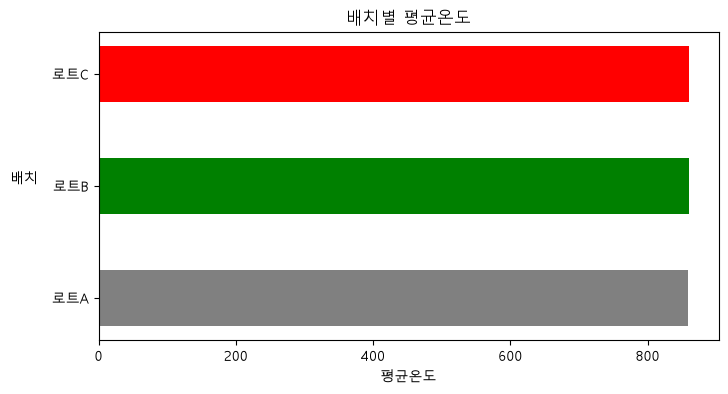

In [1]:
# [환경 설정] 한글 폰트 설정 및 필수 라이브러리 로드
# macOS, Windows, Linux, Google Colab 환경에 맞춰 한글 깨짐 없이 동작하도록 자동 감지 설정합니다.

import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

# 실습 1. 막대 그래프 직접 그리기
df = pd.read_csv('.venv/17_열처리.csv')

avg = df.groupby('배치')['온도'].mean().round(2)
print(avg.head(3))

plt.figure(figsize=(8, 4))

# plt.bar(avg.index, avg.values, width=0.5, color=['gray', 'green', 'red'])
plt.barh(avg.index, avg.values, color=['gray', 'green', 'red'], height=0.5)

plt.title('배치별 평균온도')
plt.xlabel('평균온도')
plt.ylabel('배치', rotation=0, labelpad=20)
plt.show()

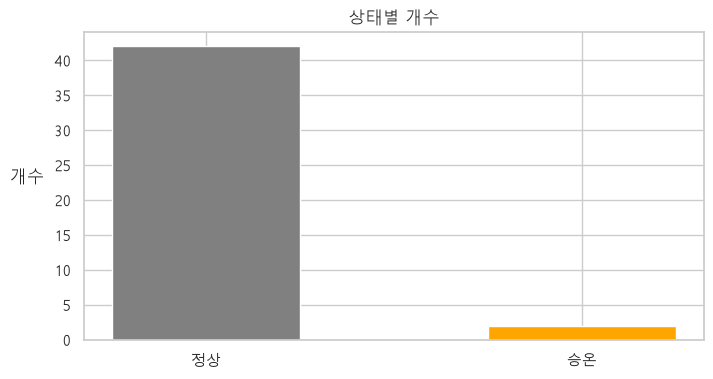

In [ ]:
status = df['상태'].value_counts()

plt.figure(figsize=(8, 4))
plt.bar(status.index, status.values, color=['gray', 'orange'], width=0.3)
plt.title('상태별 개수')
plt.ylabel('개수', rotation=0, labelpad=20)
plt.show()

배치
로트A    81.91
로트B    75.84
로트C    69.62
Name: OP값, dtype: float64


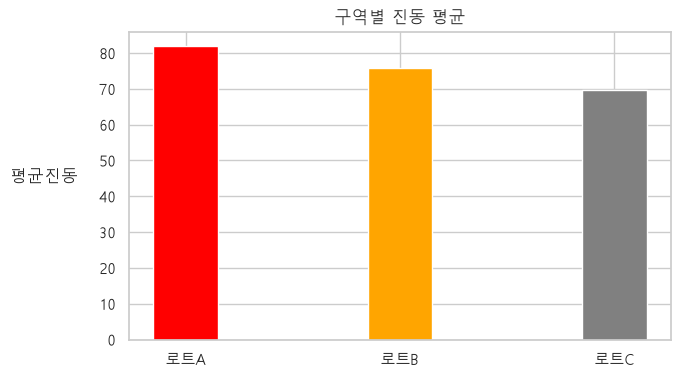

In [ ]:
# 실습 2. 범주별 집계 막대 그래프
sections = df.groupby('배치')['OP값'].mean().round(2)
print(sections.head())

plt.figure(figsize=(7, 4))
plt.bar(sections.index, sections.values, color=['red', 'orange', 'gray'], width=0.3)
plt.title('구역별 진동 평균')
plt.ylabel('평균진동', rotation=0, labelpad=40)
plt.show()


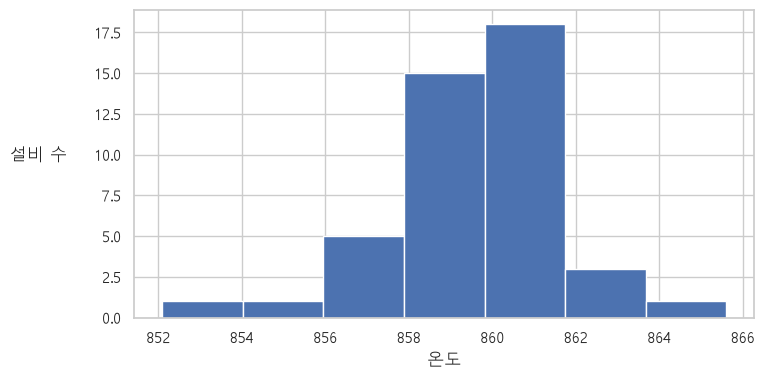

In [ ]:
# 실습 3. 히스토그램 직접 그리기
plt.figure(figsize=(8, 4))
plt.hist(df['온도'], bins=7) # 구간을 몇 개로 나올지
plt.xlabel('온도')
plt.ylabel('설비 수', rotation=0, labelpad=40)
plt.show()

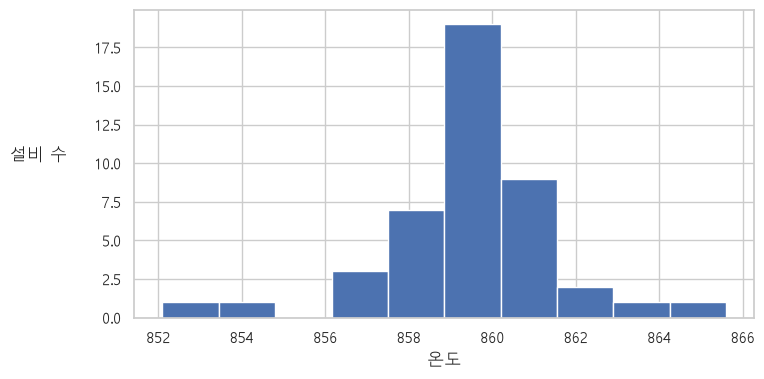

In [53]:
# 실습 4. 센서값 분포 히스토그램
# 평균온도와 표준편차를 구하기
plt.figure(figsize=(8, 4))

df_mean = df['온도'].mean()
df_std = df['온도'].std()
# plt.figure(figsize=(8, 4))
high = len(df[df['온도'] >= 862]) 
# print(high) # 2

plt.hist(df['온도'], bins=10) # 구간을 몇 개로 나올지
plt.xlabel('온도')
plt.ylabel('설비 수', rotation=0, labelpad=40)
plt.show()

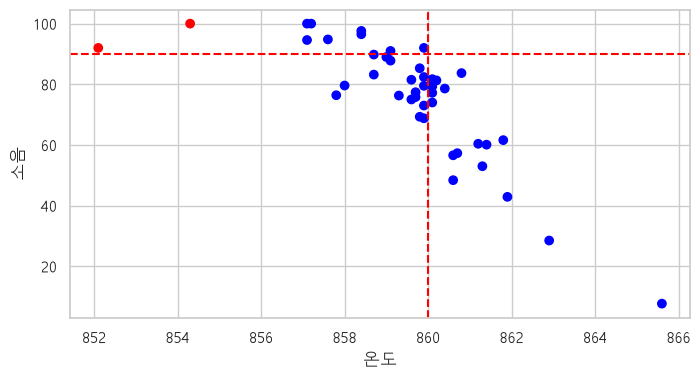

In [87]:
# 실습 5. 산점도로 센서 간 관계 분석
plt.figure(figsize=(8, 4))
colors = df['상태'].map({'정상' : 'blue', '승온' : 'red'})
plt.scatter(df['온도'], df['OP값'], color = colors)
plt.axhline(y=90, color='red', linestyle='--') # y축 기준선 그리기
plt.axvline(x=860, color='red', linestyle='--') # x축 기준선 그리기
plt.xlabel('온도')
plt.ylabel('소음')
plt.show()

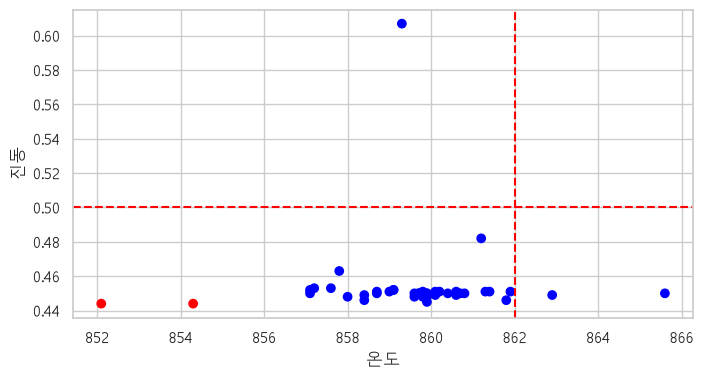

In [92]:
# 실습 6. 실습 5를 CP값(진동)으로 바꿔서 풀어보기

plt.figure(figsize=(8, 4))
colors = df['상태'].map({'정상' : 'blue', '승온' : 'red'})
plt.scatter(df['온도'], df['CP값'], color = colors)
plt.axhline(y=0.5, color='red', linestyle='--') # y축 기준선 그리기
plt.axvline(x=862, color='red', linestyle='--') # x축 기준선 그리기
plt.xlabel('온도')
plt.ylabel('진동')
plt.show()

In [ ]:
# 실습 7. SECOM 불러오기와 기초 확인
df_wide = pd.read_csv('.venv/17_열처리_공정.csv')
print(df_wide.shape) # (120, 8)
print(df_wide.isna().sum().sum()) # 25
df_wide_fill = df_wide.fillna(df_wide.mean(numeric_only=True))
print(df_wide_fill.isna().sum().sum()) # 0

(120, 8)
25
0


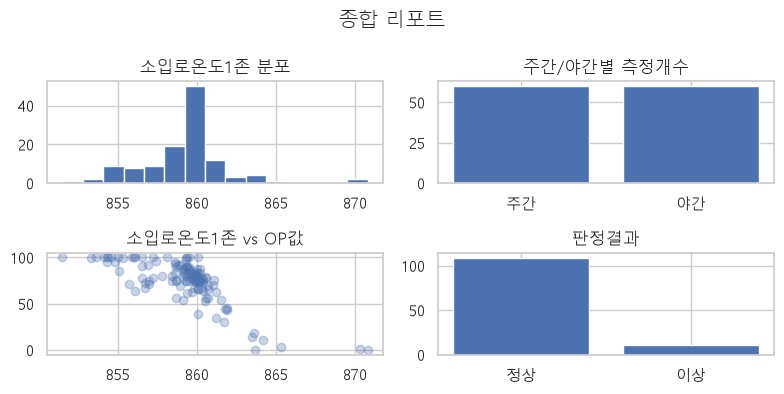

In [93]:
# 실습 8. 시각화 리포트 완성과 저장
plt.figure(figsize=(8, 4))
plt.suptitle('종합 리포트')

plt.subplot(2, 2, 4) # 가로 2, 세로 2인 종합그래프판의 1번영역을 사용
counts = df_wide_fill['result'].value_counts()
plt.bar(counts.index, counts.values)
plt.title('판정결과')
plt.subplot(2, 2, 2)
counts = df_wide_fill['라인'].value_counts()
plt.bar(counts.index, counts.values)
plt.title('주간/야간별 측정개수')
plt.subplot(2, 2, 1)
plt.hist(df_wide_fill['소입로온도1존'], bins=15)
plt.title('소입로온도1존 분포')
plt.subplot(2, 2, 3)
plt.scatter(df_wide_fill['소입로온도1존'], df_wide_fill['OP값'], alpha=0.3)
plt.title('소입로온도1존 vs OP값')

plt.tight_layout() # 칸 겹침 제거, 습관적으로 show 앞에 적용하기.
plt.show()